In [130]:
from pathlib import Path
import polars as pl
import numpy as np
import gc

In [106]:
def load_data(file_path):
    df = pl.read_csv(file_path)
    df = df.to_dummies(columns=["type"], separator="_")
    df = df.drop("step", "nameOrig", "nameDest", "isFlaggedFraud")
    df = df.with_columns(
        pl.col("isFraud").cast(pl.Int8)
    )
    return df

In [107]:
file_path_train = Path.cwd().parent.parent / "data" / "offline" / "train.csv"
file_path_test = Path.cwd().parent.parent / "data" / "offline" / "test.csv"
df_train = load_data(file_path_train)
df_test = load_data(file_path_test)

In [108]:
x_train = df_train.drop("isFraud").to_numpy()
y_train = df_train.select("isFraud").to_numpy().ravel()
x_test = df_test.drop("isFraud").to_numpy()
y_test = df_test.select("isFraud").to_numpy().ravel()

In [109]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight


sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Pass sample weights directly to fit()
# model.fit(x_train, y_train)
xgb_model.fit(x_train, y_train, sample_weight=sample_weights)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [110]:
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score, log_loss, RocCurveDisplay, PrecisionRecallDisplay


def evaluate_model(model, x_test, y_test, threshold=0.5):

    y_pred = (model.predict_proba(x_test)[:, 1] > threshold).astype(int)

    # Threshold-based evaluations

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

    prec = precision_score(y_test, y_pred, average=None)
    rec = recall_score(y_test, y_pred, average=None)
    f1 = f1_score(y_test, y_pred, average=None)
    f2 = fbeta_score(y_test, y_pred, beta=2.0, average=None)
    f3 = fbeta_score(y_test, y_pred, beta=3.0, average=None)

    ra = roc_auc_score(y_test, y_pred, average=None)
    ap = average_precision_score(y_test, y_pred, average=None)
    lo = log_loss(y_test, y_pred, labels=[0, 1])

    eval_report = {
        "model_name": model.__class__.__name__,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "f2_score": f2,
        "f3_score": f3,
        "roc_auc": ra,
        "average_precision": ap,
        "log_loss": lo
    }

    print(f"Precision - Non-Fraud: {prec[0]:.2f}, Fraud: {prec[1]:.2f}")
    print(f"Recall    - Non-Fraud: {rec[0]:.2f}, Fraud: {rec[1]:.2f}")
    print(f"F1 Score  - Non-Fraud: {f1[0]:.2f}, Fraud: {f1[1]:.2f}")
    print(f"F2 Score  - Non-Fraud: {f2[0]:.2f}, Fraud: {f2[1]:.2f}")
    print(f"F3 Score  - Non-Fraud: {f3[0]:.2f}, Fraud: {f3[1]:.2f}")

    print(f"ROC AUC: {ra:.2f}")
    print(f"Average Precision: {ap:.2f}")
    print(f"Log Loss: {lo:.2f}")

    print(ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Non-Fraud", "Fraud"]))
    print(RocCurveDisplay.from_predictions(y_test, y_pred))
    print(PrecisionRecallDisplay.from_predictions(y_test, y_pred))

    return eval_report


TN: 867170, FP: 5532, FN: 0, TP: 494
Precision - Non-Fraud: 1.00, Fraud: 0.08
Recall    - Non-Fraud: 0.99, Fraud: 1.00
F1 Score  - Non-Fraud: 1.00, Fraud: 0.15
F2 Score  - Non-Fraud: 0.99, Fraud: 0.31
F3 Score  - Non-Fraud: 0.99, Fraud: 0.47
ROC AUC: 1.00
Average Precision: 0.08
Log Loss: 0.23


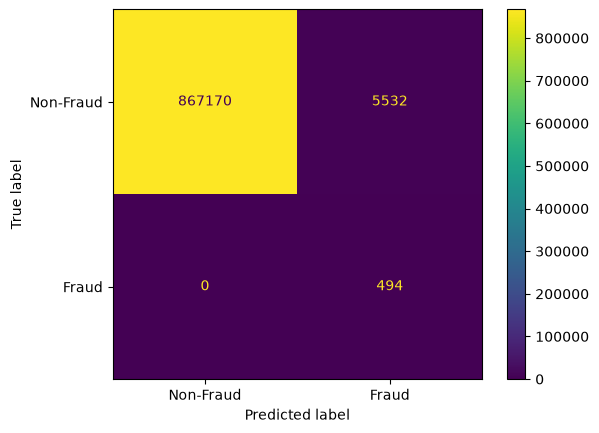

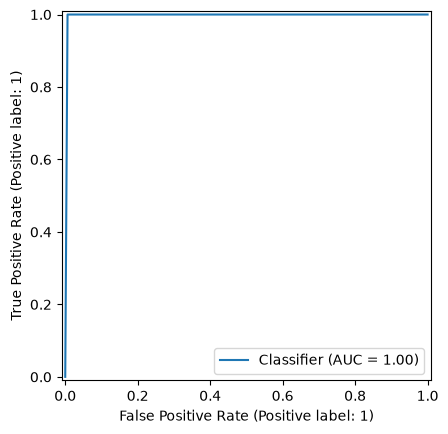

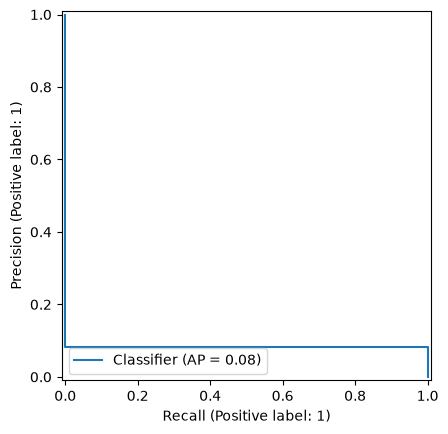

In [111]:
xgb_report = evaluate_model(xgb_model, x_test, y_test)

In [112]:
def find_best_threshold_for_metric(model, x_test, y_test, metric_function):

    best_threshold = 0
    best_metric_value = 0

    for threshold in range(100):
        y_pred = (model.predict_proba(x_test)[:, 1] > threshold / 100).astype(int)
        metric_value = metric_function(y_test, y_pred)

        if metric_value > best_metric_value:
            best_metric_value = metric_value
            best_threshold = threshold / 100

    print(f"Best threshold: {best_threshold:.2f}, Best {metric_function.__name__} value: {best_metric_value:.2f}\n")

    return best_threshold, best_metric_value

Best threshold: 0.98, Best <lambda> value: 0.80

Best threshold : 0.98 with F1 score: 0.80
TN: 872542, FP: 160, FN: 86, TP: 408
Precision - Non-Fraud: 1.00, Fraud: 0.72
Recall    - Non-Fraud: 1.00, Fraud: 0.83
F1 Score  - Non-Fraud: 1.00, Fraud: 0.77
F2 Score  - Non-Fraud: 1.00, Fraud: 0.80
F3 Score  - Non-Fraud: 1.00, Fraud: 0.81
ROC AUC: 0.91
Average Precision: 0.59
Log Loss: 0.01


{'model_name': 'XGBClassifier',
 'precision': array([0.99990145, 0.71830986]),
 'recall': array([0.99981666, 0.82591093]),
 'f1_score': array([0.99985905, 0.76836158]),
 'f2_score': array([0.99983362, 0.80188679]),
 'f3_score': array([0.99982514, 0.81372158]),
 'roc_auc': 0.9128637962657872,
 'average_precision': 0.5933584534161664,
 'log_loss': 0.010154351066339074}

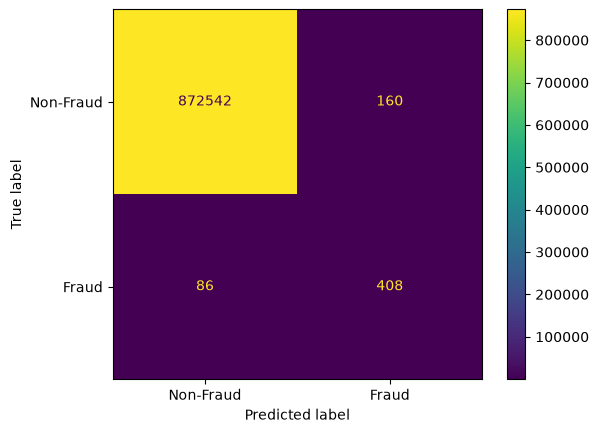

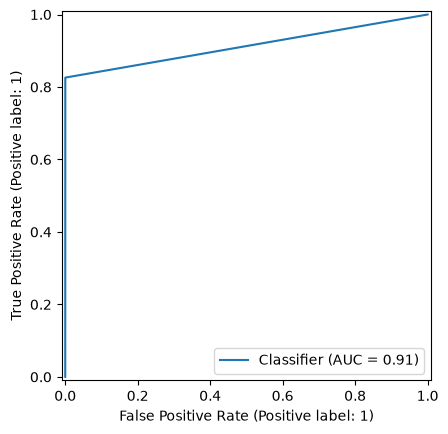

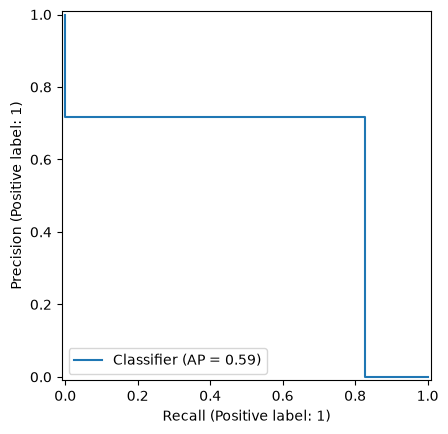

In [113]:
best_threshold, best_metric_value = find_best_threshold_for_metric(xgb_model, x_test, y_test, \
        lambda y_true, y_pred: fbeta_score(y_true, y_pred, beta=2.0)
    )

print(f"Best threshold : {best_threshold:.2f} with F1 score: {best_metric_value:.2f}")
evaluate_model(xgb_model, x_test, y_test, threshold=best_threshold)

In [114]:
from lightgbm import LGBMClassifier

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

lgbm_model = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Pass sample weights directly to fit()
# model.fit(x_train, y_train)
lgbm_model.fit(x_train, y_train, sample_weight=sample_weights)


,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


TN: 869338, FP: 3364, FN: 1, TP: 493
Precision - Non-Fraud: 1.00, Fraud: 0.13
Recall    - Non-Fraud: 1.00, Fraud: 1.00
F1 Score  - Non-Fraud: 1.00, Fraud: 0.23
F2 Score  - Non-Fraud: 1.00, Fraud: 0.42
F3 Score  - Non-Fraud: 1.00, Fraud: 0.59
ROC AUC: 1.00
Average Precision: 0.13
Log Loss: 0.14


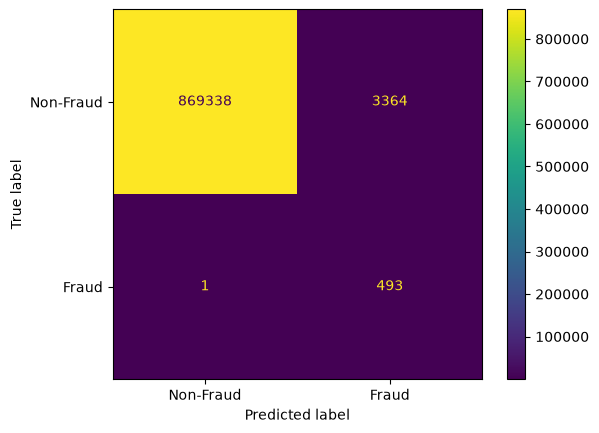

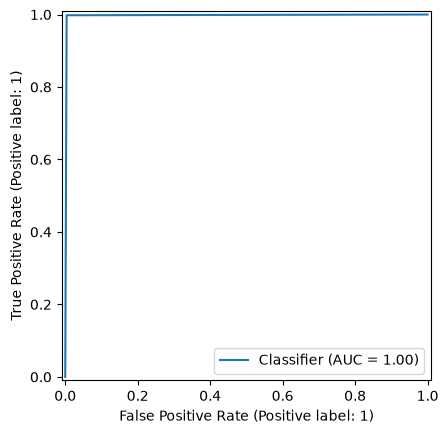

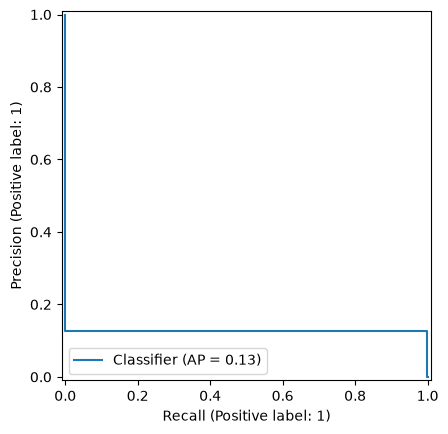

In [115]:
lgbm_report = evaluate_model(lgbm_model, x_test, y_test)

Best threshold: 0.98, Best <lambda> value: 0.80

TN: 872443, FP: 259, FN: 67, TP: 427
Precision - Non-Fraud: 1.00, Fraud: 0.62
Recall    - Non-Fraud: 1.00, Fraud: 0.86
F1 Score  - Non-Fraud: 1.00, Fraud: 0.72
F2 Score  - Non-Fraud: 1.00, Fraud: 0.80
F3 Score  - Non-Fraud: 1.00, Fraud: 0.83
ROC AUC: 0.93
Average Precision: 0.54
Log Loss: 0.01


{'model_name': 'LGBMClassifier',
 'precision': array([0.99992321, 0.62244898]),
 'recall': array([0.99970322, 0.86437247]),
 'f1_score': array([0.9998132 , 0.72372881]),
 'f2_score': array([0.99974721, 0.80202855]),
 'f3_score': array([0.99972522, 0.83203429]),
 'roc_auc': 0.9320378451040284,
 'average_precision': 0.5381044913351039,
 'log_loss': 0.013456579055392359}

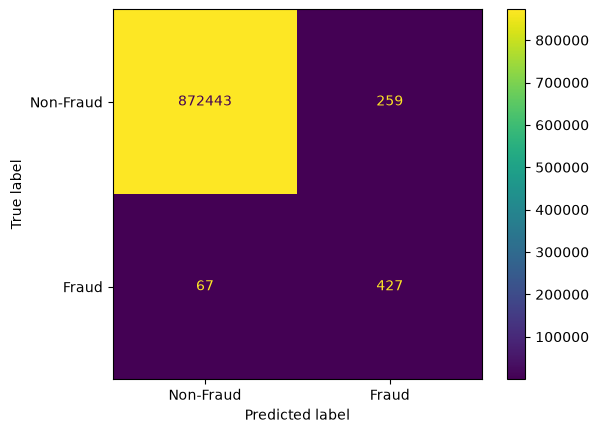

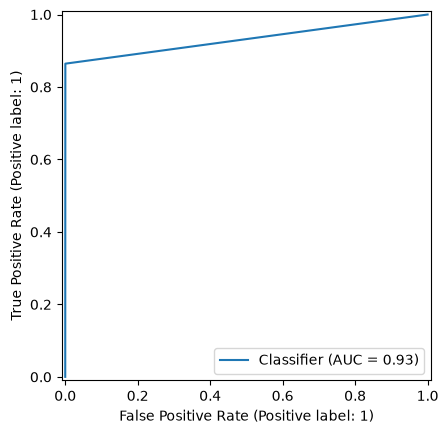

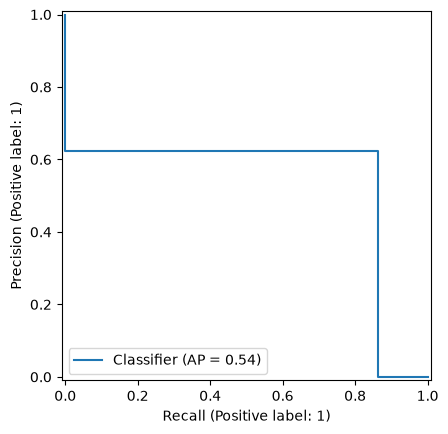

In [116]:
threshold, best_metric_value = find_best_threshold_for_metric(lgbm_model, x_test, y_test, \
        lambda y_true, y_pred: fbeta_score(y_true, y_pred, beta=2.0)
    )
evaluate_model(lgbm_model, x_test, y_test, threshold=threshold)

Best threshold: 0.99, Best average_precision_score value: 0.65

TN: 872614, FP: 88, FN: 100, TP: 394
Precision - Non-Fraud: 1.00, Fraud: 0.82
Recall    - Non-Fraud: 1.00, Fraud: 0.80
F1 Score  - Non-Fraud: 1.00, Fraud: 0.81
F2 Score  - Non-Fraud: 1.00, Fraud: 0.80
F3 Score  - Non-Fraud: 1.00, Fraud: 0.80
ROC AUC: 0.90
Average Precision: 0.65
Log Loss: 0.01


{'model_name': 'LGBMClassifier',
 'precision': array([0.99988541, 0.81742739]),
 'recall': array([0.99989916, 0.79757085]),
 'f1_score': array([0.99989229, 0.80737705]),
 'f2_score': array([0.99989641, 0.80146461]),
 'f3_score': array([0.99989779, 0.79951299]),
 'roc_auc': 0.898735006974523,
 'average_precision': 0.6520707769702937,
 'log_loss': 0.0077602357742754405}

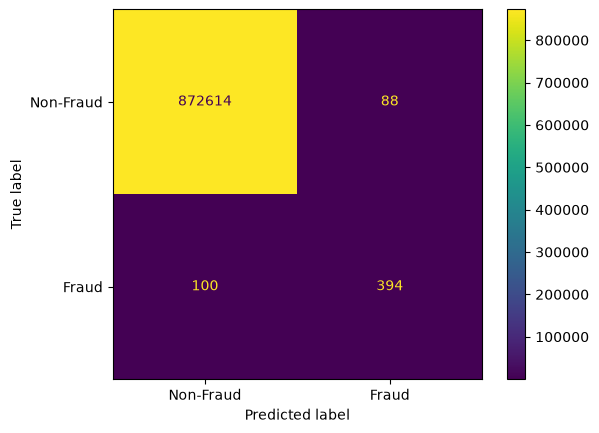

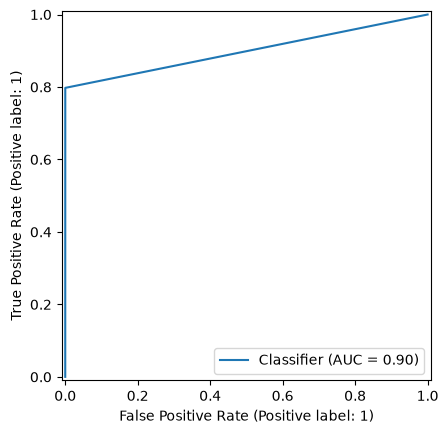

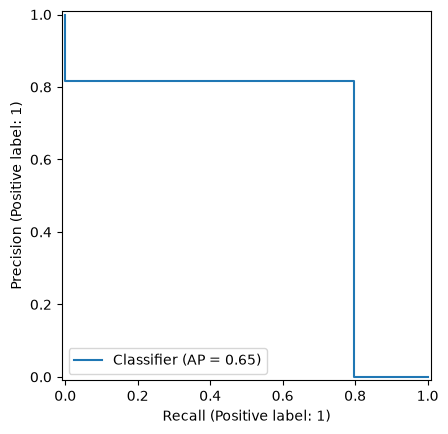

In [117]:
threshold, best_metric_value = find_best_threshold_for_metric(lgbm_model, x_test, y_test, \
        average_precision_score
    )
# 88 / 100
evaluate_model(lgbm_model, x_test, y_test, threshold=threshold)

In [ ]:
def ensemble_evaluate_model(model1, model2, x_test, y_test, weight=0.5, threshold=0.5):
    ensemble_predictions = weight * model1.predict_proba(x_test)[:, 1] + (1 - weight) * model2.predict_proba(x_test)[:, 1]
    y_pred = (ensemble_predictions > threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

    prec = precision_score(y_test, y_pred, average=None)
    rec = recall_score(y_test, y_pred, average=None)
    f1 = f1_score(y_test, y_pred, average=None)
    f2 = fbeta_score(y_test, y_pred, beta=2.0, average=None)
    f3 = fbeta_score(y_test, y_pred, beta=3.0, average=None)

    ra = roc_auc_score(y_test, y_pred, average=None)
    ap = average_precision_score(y_test, y_pred, average=None)
    lo = log_loss(y_test, y_pred, labels=[0, 1])

    eval_report = {
        "model_name": "Ensemble",
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "f2_score": f2,
        "f3_score": f3,
        "roc_auc": ra,
        "average_precision": ap,
        "log_loss": lo
    }

    print(f"Precision - Non-Fraud: {prec[0]:.2f}, Fraud: {prec[1]:.2f}")
    print(f"Recall    - Non-Fraud: {rec[0]:.2f}, Fraud: {rec[1]:.2f}")
    print(f"F1 Score  - Non-Fraud: {f1[0]:.2f}, Fraud: {f1[1]:.2f}")
    print(f"F2 Score  - Non-Fraud: {f2[0]:.2f}, Fraud: {f2[1]:.2f}")
    print(f"F3 Score  - Non-Fraud: {f3[0]:.2f}, Fraud: {f3[1]:.2f}")
    print(f"ROC AUC: {ra:.2f}")
    print(f"Average Precision: {ap:.2f}")
    print(f"Log Loss: {lo:.2f}")

    return eval_report

In [127]:
ensemble_evaluate_model(xgb_model, lgbm_model, x_test, y_test)

TN: 868482, FP: 4220, FN: 0, TP: 494
Precision - Non-Fraud: 1.00, Fraud: 0.10
Recall    - Non-Fraud: 1.00, Fraud: 1.00
F1 Score  - Non-Fraud: 1.00, Fraud: 0.19
F2 Score  - Non-Fraud: 1.00, Fraud: 0.37
F3 Score  - Non-Fraud: 1.00, Fraud: 0.54


In [ ]:
def ensemble_weight_and_threshold_search(model1, model2, x_test, y_test, metric_function, weight_range=(0.0, 1.0), threshold_range=(0.0, 1.0), step=0.1):
    
    best_weight = 0
    best_threshold = 0
    best_metric_value = 0

    count = 0

    weight_values = [round(w, 2) for w in list(np.arange(weight_range[0], weight_range[1] + step, step))]
    threshold_values = [round(t, 2) for t in list(np.arange(threshold_range[0], threshold_range[1] + step, step))]

    for weight in weight_values:
        for threshold in threshold_values:
            ensemble_predictions = weight * model1.predict_proba(x_test)[:, 1] + (1 - weight) * model2.predict_proba(x_test)[:, 1]
            y_pred = (ensemble_predictions > threshold).astype(int)
            metric_value = metric_function(y_test, y_pred)

            if metric_value > best_metric_value:
                best_metric_value = metric_value
                best_weight = weight
                best_threshold = threshold

            count += 1
            if count % 10 == 0:
                print(f"Checked {count} combinations. Current best weight: {best_weight:.2f}, best threshold: {best_threshold:.2f}, best {metric_function.__name__} value: {best_metric_value:.2f}")

    print(f"Best weight: {best_weight:.2f}, Best threshold: {best_threshold:.2f}, Best {metric_function.__name__} value: {best_metric_value:.2f}\n")

    return best_weight, best_threshold, best_metric_value
    

In [137]:
metric_function = average_precision_score
best_weight, best_threshold, best_metric_value = ensemble_weight_and_threshold_search(  
        xgb_model, lgbm_model, x_test, y_test, 
        metric_function
    )
ensemble_evaluate_model(xgb_model, lgbm_model, x_test, y_test, weight=best_weight, threshold=best_threshold)

TN: 872185, FP: 517, FN: 26, TP: 468
Precision - Non-Fraud: 1.00, Fraud: 0.48
Recall    - Non-Fraud: 1.00, Fraud: 0.95
F1 Score  - Non-Fraud: 1.00, Fraud: 0.63
F2 Score  - Non-Fraud: 1.00, Fraud: 0.79
F3 Score  - Non-Fraud: 1.00, Fraud: 0.86
ROC AUC: 0.97
Average Precision: 0.45
Log Loss: 0.02


{'model_name': 'Ensemble',
 'precision': array([0.99997019, 0.4751269 ]),
 'recall': array([0.99940759, 0.94736842]),
 'f1_score': array([0.99968881, 0.63286004]),
 'f2_score': array([0.99952006, 0.79027356]),
 'f3_score': array([0.99946382, 0.86171976]),
 'roc_auc': 0.9733880040320028,
 'average_precision': 0.4501500000935634,
 'log_loss': 0.022413872475699394}

In [144]:
print(f"Best weight: {best_weight:.2f}, Best threshold: {best_threshold:.2f}\n")

Best weight: 0.80, Best threshold: 0.95



In [142]:
import joblib
from pathlib import Path


path = Path.cwd().parent / "models"
path_xgb_model = Path(path, "xgb_model.pkl")
path_lgbm_model = Path(path, "lgbm_model.pkl")

# Save the models
joblib.dump(xgb_model, path_xgb_model)
joblib.dump(lgbm_model, path_lgbm_model)

print(f"XGBoost model saved to: {path_xgb_model}")
print(f"LGBM model saved to: {path_lgbm_model}")

XGBoost model saved to: c:\Users\MYC\Projects\realtime-fraud-detection-system\data_science\models\xgb_model.pkl
LGBM model saved to: c:\Users\MYC\Projects\realtime-fraud-detection-system\data_science\models\lgbm_model.pkl


In [143]:
import joblib

path = Path.cwd().parent / "models"
path_xgb_model = Path(path, "xgb_model.pkl")
path_lgbm_model = Path(path, "lgbm_model.pkl")
# Load model object directly
loaded_xgb_model = joblib.load(path_xgb_model)
loaded_lgbm_model = joblib.load(path_lgbm_model)

predictions_xgb = loaded_xgb_model.predict(x_test)
predictions_lgbm = loaded_lgbm_model.predict(x_test)

print(f"Predictions from loaded XGBoost model: {predictions_xgb[:10]}")
print(f"Predictions from loaded LGBM model: {predictions_lgbm[:10]}")

Predictions from loaded XGBoost model: [0 0 0 0 0 0 0 0 0 0]
Predictions from loaded LGBM model: [0 0 0 0 0 0 0 0 0 0]


In [149]:
x_test[0]

array([0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 3.69020440e+05, 5.01970000e+04, 0.00000000e+00,
       8.22299020e+05, 1.19131946e+06])